In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyproj import Geod
from scipy.optimize import root_scalar
from bluemath_tk.tcs.tracks import track_triming_circle
from numpy import polyfit

geod = Geod(ellps='WGS84')

from utils.tcs_fcts import point_from_center, compute_entrance_exit_azimuth_prolong, mean_translation_velocity, furthest_point_from_entry_exit, travel_time_linear_v, solve_velocity, interpolate_geodesic, integrate_distance


* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


In [2]:
hist_tracks_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/outputs/tracks_at_7r/hist_tracks_7r_filter.nc')
synth_tracks_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/TC_Track_Gen_v3/outputs/daily_wind/NA/tracks_all_NA_2.nc')

lon_site = -75.5730
lat_site = 36.0050
RADIUS_DEG = 7
RADIUS_KM = 777

In [3]:
df_hist_wind_pres = pd.DataFrame()
df_hist_wind_pres['wind'] = hist_tracks_nc['wmo_wind'].values.flatten() * 0.514
df_hist_wind_pres['pres'] = hist_tracks_nc['wmo_pres'].values.flatten()
df_hist_wind_pres = df_hist_wind_pres.dropna()

coeff_fit = polyfit(df_hist_wind_pres['wind'], df_hist_wind_pres['pres'], deg = 3)

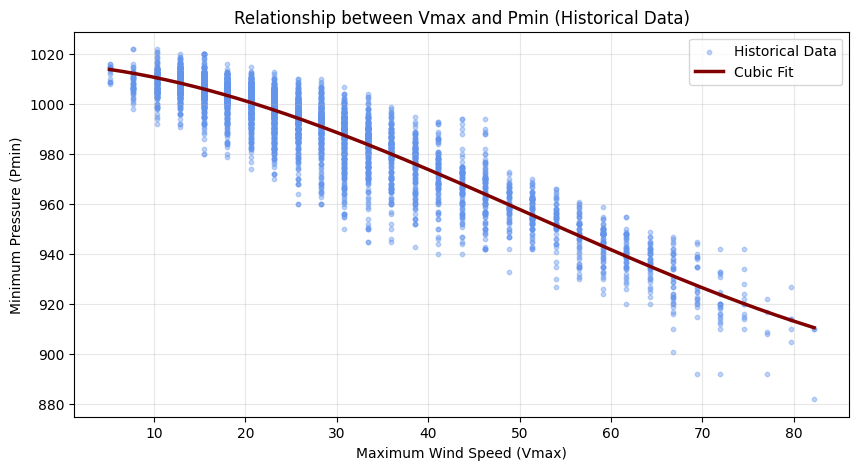

In [4]:
pfit = np.poly1d(coeff_fit)
x_fit = np.linspace(df_hist_wind_pres['wind'].min(), df_hist_wind_pres['wind'].max(), 200)
y_fit = pfit(x_fit)

plt.figure(figsize=(10,5))
plt.scatter(df_hist_wind_pres['wind'], df_hist_wind_pres['pres'], 
            s=10, color = 'cornflowerblue', alpha=0.4, label='Historical Data')
plt.plot(x_fit, y_fit, color='maroon', linewidth=2.5, label='Cubic Fit')

plt.xlabel('Maximum Wind Speed (Vmax)')
plt.ylabel('Minimum Pressure (Pmin)')
plt.title('Relationship between Vmax and Pmin (Historical Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('figures/Syntesis/03_vmax_pmin_fit_historical.png', dpi=200)

In [5]:
pmin_from_vmax = np.poly1d(coeff_fit)
pmin_values = pmin_from_vmax(synth_tracks_nc['vmax_trks'])
synth_tracks_nc = synth_tracks_nc.assign(pmin_trks=(('n_trk', 'time'), pmin_values))

In [13]:
coeff_fit

array([ 1.69367264e-04, -2.61107256e-02, -2.79782085e-01,  1.01601750e+03])

In [14]:
pfit

poly1d([ 1.69367264e-04, -2.61107256e-02, -2.79782085e-01,  1.01601750e+03])

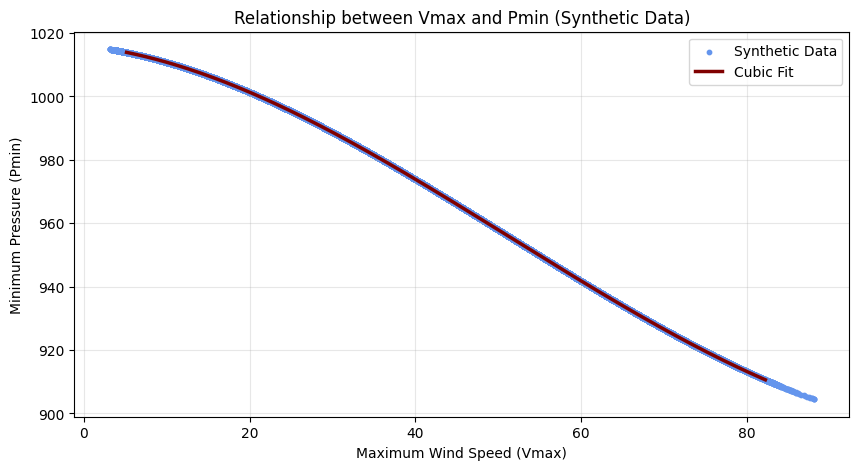

In [12]:
df_synth_wind_pres = pd.DataFrame()
df_synth_wind_pres['wind'] = synth_tracks_nc['vmax_trks'].values.flatten()
df_synth_wind_pres['pres'] = synth_tracks_nc['pmin_trks'].values.flatten()
df_synth_wind_pres = df_synth_wind_pres.dropna()


pfit = np.poly1d(coeff_fit)
x_fit = np.linspace(df_hist_wind_pres['wind'].min(), df_hist_wind_pres['wind'].max(), 200)
y_fit = pfit(x_fit)

plt.figure(figsize=(10,5))
plt.scatter(df_synth_wind_pres['wind'], df_synth_wind_pres['pres'], 
            s=10, color = 'cornflowerblue', label='Synthetic Data')
plt.plot(x_fit, y_fit, color='maroon', linewidth=2.5, label='Cubic Fit')

plt.xlabel('Maximum Wind Speed (Vmax)')
plt.ylabel('Minimum Pressure (Pmin)')
plt.title('Relationship between Vmax and Pmin (Synthetic Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('figures/Syntesis/03_vmax_pmin_fit_synthetics.png', dpi=200)

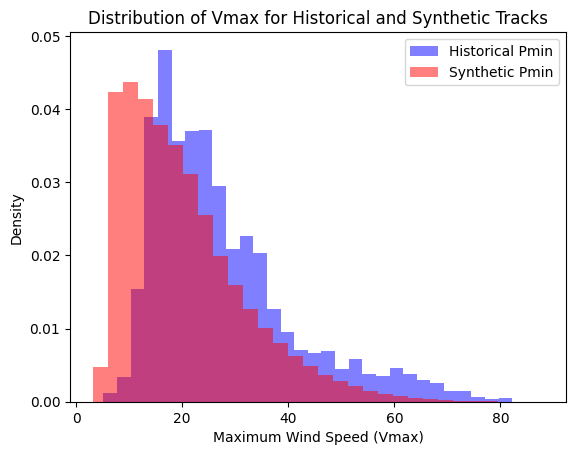

In [7]:
plt.hist(df_hist_wind_pres['wind'] , bins=30, alpha=0.5, label='Historical Pmin', color='blue', density=True)
plt.hist(df_synth_wind_pres['wind'], bins=30, alpha=0.5, label='Synthetic Pmin', color='red', density=True)
plt.xlabel('Maximum Wind Speed (Vmax)')
plt.ylabel('Density')
plt.title('Distribution of Vmax for Historical and Synthetic Tracks')
plt.legend()
plt.savefig('figures/Syntesis/03_vmax_distribution_comparison.png', dpi=200)

In [8]:
hist_LMI = np.nanmax(hist_tracks_nc.wmo_wind.values,axis=1) * 0.514
synth_LMI = np.nanmax(synth_tracks_nc.vmax_trks.values,axis=1)

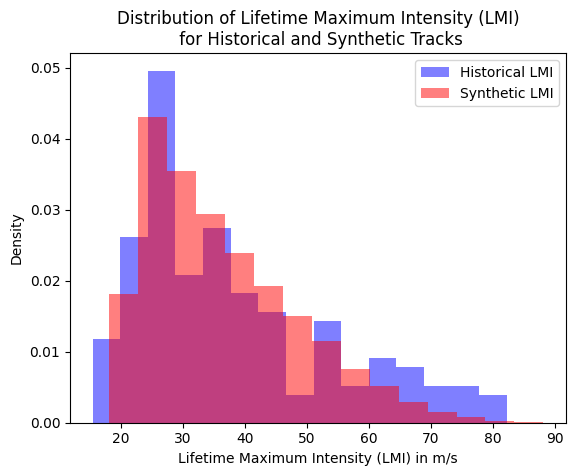

In [9]:
plt.hist(hist_LMI, bins=15, alpha=0.5, label='Historical LMI', color='blue', density=True)
plt.hist(synth_LMI, bins=15, alpha=0.5, label='Synthetic LMI', color='red', density=True)
plt.xlabel('Lifetime Maximum Intensity (LMI) in m/s')
plt.ylabel('Density')
plt.title('Distribution of Lifetime Maximum Intensity (LMI)\n for Historical and Synthetic Tracks')

plt.legend()
plt.savefig('figures/Syntesis/03_LMI_distribution_comparison.png', dpi=200)

In [10]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

# Définir les catégories et couleurs (échelle Saffir-Simpson)
def get_category_color(p_hPa):
    """Retourne la couleur et le nom de catégorie selon la pression."""
    if p_hPa < 920:
        return '#FF0000', 'CATS'      # Rouge vif
    elif p_hPa < 944:
        return '#FF6600', 'Cat 4'      # Orange foncé
    elif p_hPa < 964:
        return '#FFC800', 'Cat 3'      # Orange/Jaune
    elif p_hPa < 979:
        return '#FFFF00', 'Cat 2'      # Jaune
    elif p_hPa < 1000:
        return '#00FF00', 'Cat 1'      # Vert
    else:
        return '#00BFFF', 'TS'         # Bleu clair

# Couleurs pour la légende
category_colors = {
    'CATS': '#FF0000',
    'Cat 4': '#FF6600',
    'Cat 3': '#FFC800',
    'Cat 2': '#FFFF00',
    'Cat 1': '#00FF00',
    'TS': '#00BFFF',
}

plot = DefaultStaticPlotting()

fig2, ax2 = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Stocker les catégories présentes pour la légende
categories_present = set()

# Utiliser le dataset déjà chargé plus haut dans le notebook
# Si besoin, décommente la ligne ci-dessous:
# synth_tracks_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/TC_Track_Gen_v3/outputs/daily_wind/NA/tracks_all_NA_2.nc')

n_tracks = synth_tracks_nc.sizes['n_trk']
stride = 2  # >1 pour réduire les points tracés et la RAM

for i in range(n_tracks):
    storm = synth_tracks_nc.isel(n_trk=i)

    # Pression minimale de la trajectoire i uniquement (pas tout le dataset)
    pp = storm['pmin_trks'].min(skipna=True).item()
    color, cat_name = get_category_color(pp)
    categories_present.add(cat_name)

    # Ne charger/tracer qu'une trajectoire à la fois
    lon = (storm['lon_trks'].values - 360)[::stride]
    lat = storm['lat_trks'].values[::stride]

    valid = np.isfinite(lon) & np.isfinite(lat)
    if np.any(valid):
        ax2.plot(lon[valid], lat[valid], color=color, lw=0.8, alpha=0.7)

ax2.set_extent([-85.59778323614441, -65.57997489252989, 23.608333396911625, 44.22499866485596])
extent = ax2.get_extent(crs=ccrs.PlateCarree())

margin = 0.5
area = [
    extent[0] - margin,
    extent[1] + margin,
    extent[2] - margin,
    extent[3] + margin,
]

# Le fond satellite est coûteux; garder tel quel ou commenter pour économiser encore plus de RAM
plot.plot_satellite(ax=ax2, source="arcgis", area=area)

# Légende (seulement les catégories présentes, dans l'ordre)
legend_order = ['CATS', 'Cat 4', 'Cat 3', 'Cat 2', 'Cat 1', 'TS']
handles = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in legend_order if cat in categories_present
]
ax2.legend(handles=handles, loc='upper right', fontsize=10, title='Category')

ax2.set_extent([-85.59778323614441, -65.57997489252989, 23.608333396911625, 44.22499866485596], crs=ccrs.PlateCarree())
plt.title("Synthetic Hurricane Tracks by Category", fontsize=14)
plt.savefig('figures/Syntesis/03_synthetic_hurricane_tracks_by_category.png', dpi=200)
plt.close(fig2)

Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


In [11]:
params_list = []
df_full_list, df_small_list = [], []

for i in range(len(synth_tracks_nc['n_trk'])):
    if i % 100 == 0:
        print(f"Processing storm {i} of {len(synth_tracks_nc['n_trk'])}")
    storm = synth_tracks_nc.isel(n_trk=i)
    #name = f"{storm.name.values.item().decode('utf-8')}_{storm.time.values[0].astype('datetime64[Y]').astype(int) + 1970}"

    df_full = pd.DataFrame({
        'time': storm['time'].values,
        'lat': storm['lat_trks'].values,
        'lon': ((storm['lon_trks'].values + 180) % 360) - 180,
        'pmin': storm['pmin_trks'].values,
#        'vmax': storm['wmo_wind'].values
    }).dropna()
    #df_full_list.append(df_full.copy())
    ref_time = pd.Timestamp("2000-01-01 00:00:00")
    df_full["time"] = ref_time + pd.to_timedelta(df_full["time"], unit="s")

    df = df_full.drop_duplicates(subset='time').set_index('time')
    df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='H')).interpolate()
    try:
        df_small = track_triming_circle(df, lon_site, lat_site, RADIUS_DEG)
    except:
        continue
    if len(df_small) < 10:
        continue

    df_full_list.append(df_full.copy())
    df_small_list.append(df_small.copy())

    entr_az, entr_d, exit_az, exit_d = compute_entrance_exit_azimuth_prolong(df_small, lat_site, lon_site)
    fur_idx, fur_dist, fur_az = furthest_point_from_entry_exit(df_small, lat_site, lon_site)
    fur_pos = df_small.index.get_loc(fur_idx)
    
    p_entr, p_fur, p_exit = df_small.iloc[0]['pmin'], df_small.iloc[fur_pos]['pmin'], df_small.iloc[-1]['pmin']

    lon_f, lat_f = df_small.iloc[fur_pos][['lon', 'lat']]

    d12_obs = geod.inv(df_small.iloc[0]['lon'], df_small.iloc[0]['lat'], lon_f, lat_f)[2] / 1000
    d23_obs = geod.inv(lon_f, lat_f, df_small.iloc[-1]['lon'], df_small.iloc[-1]['lat'])[2] / 1000

    v_fur = (mean_translation_velocity(df_small, fur_pos-1, fur_pos) + 
             mean_translation_velocity(df_small, fur_pos, fur_pos+1)) / 2
    t1 = (df_small.index[fur_pos] - df_small.index[0]).total_seconds() / 3600
    t2 = (df_small.index[-1] - df_small.index[fur_pos]).total_seconds() / 3600
    v_entr = solve_velocity(d12_obs, t1, v_fur)
    v_exit = solve_velocity(d23_obs, t2, v_fur)
    
    params_list.append({
    #    'name': name,
        'date_furthest': df_small.index[fur_pos],
        'azimuth_entrance': entr_az,
        'distance_entrance': entr_d,
        'azimuth_exit': exit_az,
        'distance_exit': exit_d,
        'azimuth_furthest': fur_az,
        'distance_furthest_km': fur_dist,
        'p_furthest_hPa': p_fur,
        'p_entrance_hPa': p_entr,
        'p_exit_hPa': p_exit,
        'vmean_entrance_kmh': v_entr,
        'vmean_furthest_kmh': v_fur,
        'vmean_exit_kmh': v_exit
    })

print(f"Extraction terminée: {len(params_list)} tracks")


Processing storm 0 of 34886
Processing storm 100 of 34886
Processing storm 200 of 34886
Processing storm 300 of 34886
Processing storm 400 of 34886
Processing storm 500 of 34886
Processing storm 600 of 34886
Processing storm 700 of 34886
Processing storm 800 of 34886
Processing storm 900 of 34886
Processing storm 1000 of 34886
Processing storm 1100 of 34886
Processing storm 1200 of 34886
Processing storm 1300 of 34886
Processing storm 1400 of 34886
Processing storm 1500 of 34886
Processing storm 1600 of 34886
Processing storm 1700 of 34886
Processing storm 1800 of 34886
Processing storm 1900 of 34886
Processing storm 2000 of 34886
Processing storm 2100 of 34886
Processing storm 2200 of 34886
Processing storm 2300 of 34886
Processing storm 2400 of 34886
Processing storm 2500 of 34886
Processing storm 2600 of 34886
Processing storm 2700 of 34886
Processing storm 2800 of 34886
Processing storm 2900 of 34886
Processing storm 3000 of 34886
Processing storm 3100 of 34886
Processing storm 320

KeyboardInterrupt: 

In [ ]:
df_synth_list = []

for i, p in enumerate(params_list):
    v_entr, v_fur, v_exit = p['vmean_entrance_kmh'], p['vmean_furthest_kmh'], p['vmean_exit_kmh']
    
    # Skip invalid velocities
    if v_entr <= 0 or v_fur <= 0 or v_exit <= 0:
        df_synth_list.append(None)
        continue

    lat_f, lon_f = point_from_center(lat_site, lon_site, p['azimuth_furthest'], p['distance_furthest_km'])
    lat_e, lon_e = point_from_center(lat_site, lon_site, p['azimuth_entrance'],  p['distance_entrance'])
    lat_x, lon_x = point_from_center(lat_site, lon_site, p['azimuth_exit'], p['distance_exit'])

    d_fur_to_entry = geod.inv(lon_f, lat_f, lon_e, lat_e)[2] / 1000
    d_fur_to_exit = geod.inv(lon_f, lat_f, lon_x, lat_x)[2] / 1000

    dt1 = travel_time_linear_v(d_fur_to_entry, v_fur, v_entr)
    dt2 = travel_time_linear_v(d_fur_to_exit, v_fur, v_exit)
    
    if np.isnan(dt1) or np.isnan(dt2):
        df_synth_list.append(None)
        continue

    t1_arr, v1_arr, d1_arr = integrate_distance(v_fur, v_entr, dt1)

    t1_arr, v1_arr, d1_arr = t1_arr[::-1], v1_arr[::-1], d1_arr[-1] - d1_arr[::-1]
    lat1, lon1 = interpolate_geodesic(lat_e, lon_e, lat_f, lon_f, d1_arr)
    
    t2_arr, v2_arr, d2_arr = integrate_distance(v_fur, v_exit, dt2)
    lat2, lon2 = interpolate_geodesic(lat_f, lon_f, lat_x, lon_x, d2_arr)

    p_entr, p_fur, p_exit = p['p_entrance_hPa'], p['p_furthest_hPa'], p['p_exit_hPa']

    n1, n2 = len(t1_arr), len(t2_arr)
    date_fur = pd.to_datetime(p['date_furthest'])
    time_index = pd.date_range(
        start=date_fur - pd.Timedelta(hours=n1-1),
        periods=n1 + n2 - 1,
        freq='H'
    )
    
    df_synth = pd.DataFrame({
        'lat': np.concatenate([lat1, lat2[1:]]),
        'lon': np.concatenate([lon1, lon2[1:]]),
        'pmin': np.concatenate([np.linspace(p_entr, p_fur, n1), 
                                np.linspace(p_fur, p_exit, n2)[1:]]),
        'vmean': np.concatenate([v1_arr[:-1], [v_fur], v2_arr[1:]])
    }, index=time_index)
    df_synth_list.append(df_synth)

    #if i%100 == 0:
    print(f"Plotting storm {i} of {len(params_list)}")

    fig = plt.figure(figsize=(15, 5))

    ax1 = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree())
    ax1.add_feature(cfeature.COASTLINE); ax1.add_feature(cfeature.LAND, alpha=0.3)
    ax1.plot(df_full_list[i]['lon'], df_full_list[i]['lat'], 'k-', lw=1, label='Full')
    ax1.plot(df_small_list[i]['lon'], df_small_list[i]['lat'], 'r-', lw=2, label='Obs 7°')
    ax1.plot(df_synth['lon'], df_synth['lat'], 'b--', marker='o', ms=0.5, lw=0.1, label='Synth')
    angles = np.linspace(0, 2 * np.pi, 361)
    ax1.plot(lon_site + RADIUS_DEG * np.cos(angles) / np.cos(np.radians(lat_site)),
            lat_site + RADIUS_DEG * np.sin(angles), 'k--', lw=1)
    #ax1.set_title(p['name']); ax1.legend(fontsize=7)
    
    ax2 = plt.subplot(1, 3, 2)
    ax2 = plt.subplot(1, 3, 2)
    ax2.plot(df_small_list[i].index, df_small_list[i]['pmin'].values, 'r-', lw=2, label='Obs')
    ax2.plot(df_synth.index, df_synth['pmin'].values, 'b--', lw=2, label='Synth')
    ax2.axvline(date_fur, color='green', ls=':', lw=1, label='Furthest')
    ax2.set_ylabel('Pressure (hPa)')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax3 = plt.subplot(1, 3, 3)
    t_vel_obs = df_small_list[i].index[:-1]  # velocity is between points
    v_obs = [mean_translation_velocity(df_small_list[i], j, j+1) for j in range(len(df_small_list[i])-1)]
    ax3.plot(t_vel_obs, v_obs, 'r-', lw=2, label='Obs')
    ax3.plot(df_synth.index, df_synth['vmean'].values, 'b--', lw=2, label='Synth')
    ax3.axvline(date_fur, color='green', ls=':', lw=1, label='Furthest')
    ax3.set_ylabel('Velocity (km/h)')
    ax3.legend(); ax3.grid(alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(f'figures/03_syntetic_params/storm_{i}_comparison.png', dpi=200)
    plt.close()


Plotting storm 0 of 13184
Plotting storm 1 of 13184
Plotting storm 2 of 13184
Plotting storm 3 of 13184
Plotting storm 4 of 13184
Plotting storm 5 of 13184
Plotting storm 6 of 13184
Plotting storm 7 of 13184
Plotting storm 8 of 13184
Plotting storm 9 of 13184
Plotting storm 10 of 13184
Plotting storm 11 of 13184
Plotting storm 12 of 13184
Plotting storm 13 of 13184
Plotting storm 14 of 13184
Plotting storm 15 of 13184
Plotting storm 16 of 13184
Plotting storm 17 of 13184
Plotting storm 18 of 13184
Plotting storm 19 of 13184
Plotting storm 20 of 13184
Plotting storm 21 of 13184
Plotting storm 22 of 13184
Plotting storm 23 of 13184
Plotting storm 24 of 13184
Plotting storm 25 of 13184
Plotting storm 26 of 13184
Plotting storm 27 of 13184
Plotting storm 28 of 13184
Plotting storm 29 of 13184
Plotting storm 30 of 13184
Plotting storm 31 of 13184
Plotting storm 32 of 13184
Plotting storm 33 of 13184
Plotting storm 34 of 13184
Plotting storm 35 of 13184
Plotting storm 36 of 13184
Plotting st

In [ ]:
valid_synth = [(i, df) for i, df in enumerate(df_synth_list) if df is not None]
valid_indices = [i for i, df in valid_synth]

In [ ]:
params_valid = [params_list[i] for i in valid_indices]
df_params = pd.DataFrame(params_valid)
#df_params['bmus'] = hist_tracks_nc['bmus'].values
df_params.to_csv('outputs/syntetic_tracks_7r_params.csv', index=False)
df_params

,date_furthest,azimuth_entrance,distance_entrance,azimuth_exit,distance_exit,azimuth_furthest,distance_furthest_km,p_furthest_hPa,p_entrance_hPa,p_exit_hPa,vmean_entrance_kmh,vmean_furthest_kmh,vmean_exit_kmh
0,2000-01-08 22:00:00,177.719087,773.901253,48.566770,760.071837,89.739119,412.106890,1000.299621,994.470343,1003.972938,43.128626,53.152029,51.855053
1,2000-01-10 16:00:00,143.132065,763.772384,77.196057,752.395017,108.099855,611.664535,1006.934131,1005.751253,1007.499586,41.702667,56.359839,73.505913
2,2000-01-04 16:00:00,242.046138,764.523754,337.078755,760.723750,255.426095,550.708001,1009.992257,1008.344215,1013.131241,52.355686,52.330823,56.621322
3,2000-01-09 01:00:00,200.761073,772.267422,109.908886,773.186746,218.492458,424.063107,1006.707026,1004.102245,1007.827385,15.652328,11.475800,13.395999
4,2000-01-13 21:00:00,151.695460,754.535602,73.166860,761.730646,136.280703,553.340763,958.586550,953.153471,954.880882,30.233394,36.291348,60.409235
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13179,2000-01-03 20:00:00,239.226643,768.013004,337.842416,178.783764,223.955308,432.907076,1011.083223,1010.288755,1013.443706,45.280196,9.623877,26.320195
13180,2000-01-06 13:00:00,237.226297,749.173529,53.615454,766.119864,60.522525,490.658479,1012.199768,1006.393286,1012.401104,25.096406,71.336059,44.782570
13181,2000-01-08 00:00:00,170.842094,756.433455,51.198805,764.234725,162.697444,525.461469,977.691633,984.755140,977.284923,34.249932,49.208074,112.936411
13182,2000-01-06 03:00:00,252.052355,776.409297,172.819014,464.038743,226.793577,454.642026,1013.217366,1012.250534,1013.474759,38.227003,36.932411,32.605414


In [ ]:
max_len = max(len(df) for _, df in valid_synth)

def pad_array(arr, length):
    out = np.full(length, np.nan)
    out[:len(arr)] = arr
    return out

ds = xr.Dataset(
    data_vars={
        'lat': (['storm', 'time'], [pad_array(df['lat'].values, max_len) for _, df in valid_synth]),
        'lon': (['storm', 'time'], [pad_array(df['lon'].values, max_len) for _, df in valid_synth]),
        'pmin': (['storm', 'time'], [pad_array(df['pmin'].values, max_len) for _, df in valid_synth]),
    },
    coords={
        'date': ('storm', [str(df_synth_list[i].index[0]) for i, _ in valid_synth]),
        'time': np.arange(max_len),
    },
    attrs={'description': 'Synthetic TC tracks'}
)
ds.to_netcdf('outputs/syntetic_tracks_7r.nc')
ds


<xarray.Dataset> Size: 304MB
Dimensions:  (storm: 13184, time: 958)
Coordinates:
  * time     (time) int64 8kB 0 1 2 3 4 5 6 7 ... 951 952 953 954 955 956 957
    date     (storm) <U19 1MB '2000-01-08 04:00:00' ... '2000-01-10 06:00:00'
Dimensions without coordinates: storm
Data variables:
    lat      (storm, time) float64 101MB 29.03 29.38 29.73 30.09 ... nan nan nan
    lon      (storm, time) float64 101MB -75.26 -75.06 -74.86 ... nan nan nan
    pmin     (storm, time) float64 101MB 994.5 994.8 995.1 995.4 ... nan nan nan
Attributes:
    description:  Synthetic TC tracks

Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


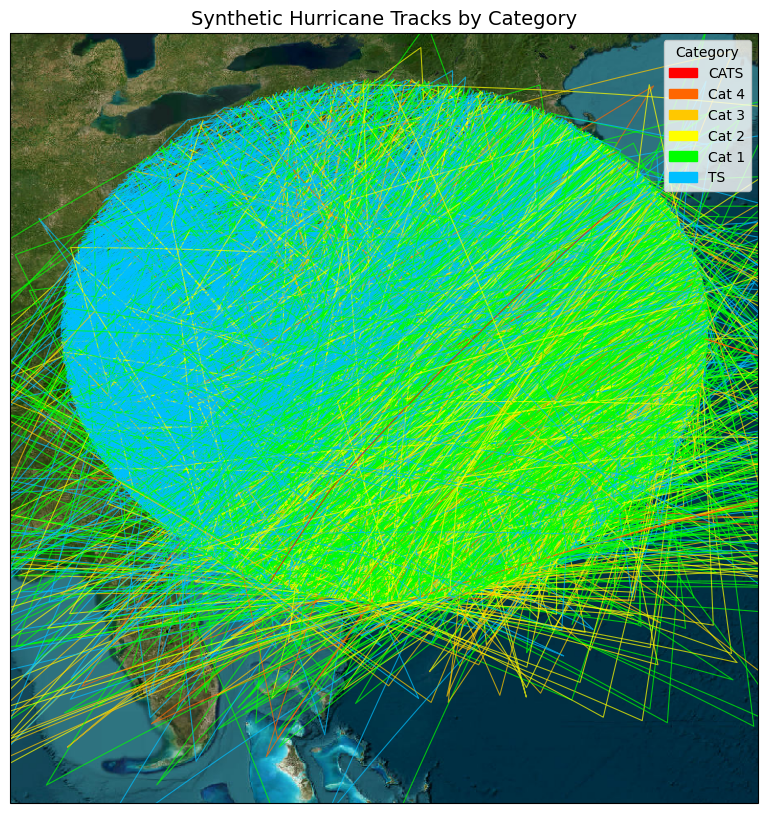

In [ ]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

# Définir les catégories et couleurs (échelle Saffir-Simpson)
def get_category_color(p_hPa):
    """Retourne la couleur et le nom de catégorie selon la pression."""
    if p_hPa < 920:
        return '#FF0000', 'CATS'      # Rouge vif
    elif p_hPa < 944:
        return '#FF6600', 'Cat 4'      # Orange foncé
    elif p_hPa < 964:
        return '#FFC800', 'Cat 3'      # Orange/Jaune
    elif p_hPa < 979:
        return '#FFFF00', 'Cat 2'      # Jaune
    elif p_hPa < 1000:
        return '#00FF00', 'Cat 1'      # Vert
    else:
        return '#00BFFF', 'TS'         # Bleu clair

# Couleurs pour la légende
category_colors = {
    'CATS': '#FF0000',
    'Cat 4': '#FF6600',
    'Cat 3': '#FFC800',
    'Cat 2': '#FFFF00',
    'Cat 1': '#00FF00',
    'TS': '#00BFFF',
}

plot = DefaultStaticPlotting()

fig2, ax2 = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Stocker les catégories présentes pour la légende
categories_present = set()

for i, p in enumerate(params_valid):
    v_entr, v_fur, v_exit = p['vmean_entrance_kmh'], p['vmean_furthest_kmh'], p['vmean_exit_kmh']
    
    if v_entr <= 0 or v_fur <= 0 or v_exit <= 0:
        continue

    lat_f, lon_f = point_from_center(lat_site, lon_site, p['azimuth_furthest'], p['distance_furthest_km'])
    lat_e, lon_e = point_from_center(lat_site, lon_site, p['azimuth_entrance'],  p['distance_entrance'])
    lat_x, lon_x = point_from_center(lat_site, lon_site, p['azimuth_exit'], p['distance_exit'])

    d_fur_to_entry = geod.inv(lon_f, lat_f, lon_e, lat_e)[2] / 1000
    d_fur_to_exit = geod.inv(lon_f, lat_f, lon_x, lat_x)[2] / 1000

    dt1 = travel_time_linear_v(d_fur_to_entry, v_fur, v_entr)
    dt2 = travel_time_linear_v(d_fur_to_exit, v_fur, v_exit)
    
    if np.isnan(dt1) or np.isnan(dt2):
        continue

    t1_arr, v1_arr, d1_arr = integrate_distance(v_fur, v_entr, dt1)
    t1_arr, v1_arr, d1_arr = t1_arr[::-1], v1_arr[::-1], d1_arr[-1] - d1_arr[::-1]
    lat1, lon1 = interpolate_geodesic(lat_e, lon_e, lat_f, lon_f, d1_arr)
    
    t2_arr, v2_arr, d2_arr = integrate_distance(v_fur, v_exit, dt2)
    lat2, lon2 = interpolate_geodesic(lat_f, lon_f, lat_x, lon_x, d2_arr)

    p_entr, p_fur, p_exit = p['p_entrance_hPa'], p['p_furthest_hPa'], p['p_exit_hPa']

    n1, n2 = len(t1_arr), len(t2_arr)
    time_index = pd.date_range(
        start=p['date_furthest'] - pd.Timedelta(hours=n1-1),
        periods=n1 + n2 - 1,
        freq='H'
    )
    
    df_synth = pd.DataFrame({
        'lat': np.concatenate([lat1, lat2[1:]]),
        'lon': np.concatenate([lon1, lon2[1:]]),
        'pmin': np.concatenate([np.linspace(p_entr, p_fur, n1), 
                                np.linspace(p_fur, p_exit, n2)[1:]]),
        'vmean': np.concatenate([v1_arr[:-1], [v_fur], v2_arr[1:]])
    }, index=time_index)
    
    # Couleur basée sur p_furthest
    pp = np.min((p_entr, p_fur, p_exit))
    color, cat_name = get_category_color(pp)
    categories_present.add(cat_name)
    
    ax2.plot(df_synth['lon'], df_synth['lat'], color=color, lw=0.8, alpha=0.7)

ax2.autoscale()
ax2.set_extent([-85.59778323614441, -65.57997489252989, 23.608333396911625, 44.22499866485596])
extent = ax2.get_extent(crs=ccrs.PlateCarree())

margin = 0.5
area = [
    extent[0] - margin,
    extent[1] + margin,
    extent[2] - margin,
    extent[3] + margin,
]

plot.plot_satellite(ax=ax2, source="arcgis", area=area)

# Légende (seulement les catégories présentes, dans l'ordre)
legend_order = ['CATS', 'Cat 4', 'Cat 3', 'Cat 2', 'Cat 1', 'TS']
handles = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in legend_order if cat in categories_present
]
ax2.legend(handles=handles, loc='upper right', fontsize=10, title='Category')

ax2.set_extent([-85.59778323614441, -65.57997489252989, 23.608333396911625, 44.22499866485596], crs=ccrs.PlateCarree())
plt.title("Synthetic Hurricane Tracks by Category", fontsize=14)
plt.savefig('figures/Syntesis/03_synthetic_hurricane_tracks_by_category.png', dpi=200)